Colab Cell 1: Setup & Data Download

This cell installs dependencies and downloads the dataset. When you run it, a "Choose Files" button will appear

In [ ]:
"""
import os
from google.colab import userdata

# 1. Fetch your secrets from Colab (everyone have to do it from their kaggle)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 2. Install/Update the Kaggle library
!pip install -q kaggle

# 3. Download the specific CAPTCHA dataset (can change later)
# Use the -d flag followed by the dataset path from the URL
!kaggle datasets download -d parsasam/captcha-dataset

# 4. Create a folder and unzip
!mkdir -p dataset
!unzip -q captcha-dataset.zip -d dataset
!rm captcha-dataset.zip

print("Dataset is ready! You can see it in the folder icon on the left.")
"""

'\nimport os\nfrom google.colab import userdata\n\n# 1. Fetch your secrets from Colab (everyone have to do it from their kaggle)\nos.environ[\'KAGGLE_USERNAME\'] = userdata.get(\'KAGGLE_USERNAME\')\nos.environ[\'KAGGLE_KEY\'] = userdata.get(\'KAGGLE_KEY\')\n\n# 2. Install/Update the Kaggle library\n!pip install -q kaggle\n\n# 3. Download the specific CAPTCHA dataset (can change later)\n# Use the -d flag followed by the dataset path from the URL\n!kaggle datasets download -d parsasam/captcha-dataset\n\n# 4. Create a folder and unzip\n!mkdir -p dataset\n!unzip -q captcha-dataset.zip -d dataset\n!rm captcha-dataset.zip\n\nprint("Dataset is ready! You can see it in the folder icon on the left.")\n'

In [ ]:
"""
import os
files = os.listdir('dataset')
print(f"Found {len(files)} images. First 5: {files[:5]}")
"""

'\nimport os\nfiles = os.listdir(\'dataset\')\nprint(f"Found {len(files)} images. First 5: {files[:5]}")\n'

this code load the dataset

In [ ]:
import os
from google.colab import userdata
from huggingface_hub import snapshot_download

# 1. Setup (Optional: only needed if the dataset is private)
# hf_token = userdata.get('HF_TOKEN')

# 2. Install Hugging Face Hub
!pip install -q huggingface_hub
!pip install -q datasets

# 3. Download the dataset
# This downloads the files to a local folder named 'dataset'
repo_id = "hammer888/captcha-data"
local_dir = "./dataset"

print(f"Downloading {repo_id}...")
snapshot_download(
    repo_id=repo_id,
    local_dir=local_dir,
    repo_type="dataset",
    # token=hf_token # Uncomment this line if you added the HF_TOKEN secret
)

print(f"Dataset ready in {local_dir}!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Dataset ready in ./dataset!


In [ ]:
import os
files = os.listdir('./dataset/data')
print(f"Total files: {len(files)}")
print(f"Sample filenames: {files[:5]}")

#print a visualisation of the the data



Total files: 14
Sample filenames: ['train-00013-of-00018-0a8dcca12f2c0f4c.parquet', 'train-00001-of-00018-b48390c01b2ad6ff.parquet', 'train-00008-of-00018-780becf52e592d52.parquet', 'train-00000-of-00018-21d883f358439145.parquet', 'train-00009-of-00018-328b75846313b335.parquet']


Colab Cell 2: Data Processing & Mapping

The CRNN needs a "vocabulary" (mapping letters to numbers). We'll also define a custom Dataset class to read the filenames.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from datasets import load_dataset

# 1. Load the Parquet files into a Hugging Face Dataset object
print("Loading Parquet files...")
hf_data_full = load_dataset("parquet", data_files="./dataset/data/*.parquet", split="train")


Loading Parquet files...


Generating train split: 0 examples [00:00, ? examples/s]

In [1]:
# ==============================================================================
# 🎛️ MASTER CONFIGURATION / HYPERPARAMETER CONTROL PANEL 🎛️
# Run this cell first before setting up the model or data!
# ==============================================================================

# --- 1. DATA LIMITS & SPLITTING ---
MAX_DATA_SAMPLES = 100000       # Set to an int (e.g., 1000) for fast testing, or None to use all data
TRAIN_PERCENTAGE = 0.80       # 0.90 means 90% for training, 10% for testing/validation

# --- 2. IMAGE PREPROCESSING ---
IMG_WIDTH = 200               # Width to resize all images to
IMG_HEIGHT = 50               # Height to resize all images to

# --- 3. TRAINING HYPERPARAMETERS ---
BATCH_SIZE = 64               # Number of images to process simultaneously (Lower if out of memory)
EPOCHS = 10                   # Number of times the AI will see the entire dataset
LEARNING_RATE = 0.0001         # How drastically the model changes its mind (Default Adam is 0.001)

# --- 4. MODEL ARCHITECTURE CAPACITY ---
RNN_HIDDEN_SIZE = 256         # The "memory capacity" of the sequence reader
RNN_LAYERS = 2                # How many RNNs are stacked on top of each other

# --- 5. ALPHABET & MAPPING ---
# Define every character the AI is allowed to guess.
CHARACTERS = "abcdefghijklmnopqrstuvwxyz0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
print(len(CHARACTERS))

# (Automatic Generation of the mapping dictionaries)
CHAR_TO_NUM = {char: i + 1 for i, char in enumerate(sorted(list(CHARACTERS)))}
NUM_TO_CHAR = {i: char for char, i in CHAR_TO_NUM.items()}
NUM_TO_CHAR[0] = "" # Reserve index 0 for the CTC Blank token



62


In [ ]:




if MAX_DATA_SAMPLES is not None:
    hf_data = hf_data_full.select(range(MAX_DATA_SAMPLES))
else :
    hf_data = hf_data_full

# Good practice: Print the column names to see how the data is structured
# (Usually they are named 'image' and 'label', or 'image' and 'text')
print(f"Columns inside the parquet: {hf_data.column_names}")

# 2. Updated PyTorch Dataset
class CaptchaDataset(Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # Fetch the row from the parquet file
        row = self.hf_dataset[idx]

        # NOTE: If your column_names printed above say 'text' instead of 'label', change it here!
        image = row['image']
        label_text = row['text']
        label_text = row['text'].split("'")[1]

        # Hugging Face automatically decodes the parquet into a PIL Image
        image = image.convert("L")
        image = self.transform(image)

        label = [CHAR_TO_NUM[c] for c in label_text]
        return image, torch.LongTensor(label), len(label)

# 3. Split and Load
full_dataset = CaptchaDataset(hf_data)

train_size = int(TRAIN_PERCENTAGE * len(full_dataset))
train_ds, test_ds = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset) - train_size])

# 1. Define how to bundle the batch together
def custom_collate_fn(batch):
    images, labels, label_lengths = zip(*batch)

    # Stack images normally -> Shape: [Batch_Size, 1, 50, 200]
    images = torch.stack(images, 0)

    # Concatenate labels into one long 1D tensor -> Shape: [Sum_of_all_lengths]
    labels = torch.cat(labels, 0)

    # Bundle lengths into a 1D tensor -> Shape: [Batch_Size]
    label_lengths = torch.tensor(label_lengths, dtype=torch.long)

    return images, labels, label_lengths

NUM_CORES = os.cpu_count(); # parallelism

# 2. Update your DataLoaders to use this rule
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=custom_collate_fn,
    num_workers=NUM_CORES,   # <--- Parallel CPU fetching
    pin_memory=True          # <--- Fast-lane transfer to GPU
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=custom_collate_fn
)

print(f"Successfully loaded! Training samples: {len(train_ds)}, Test samples: {len(test_ds)}")

Columns inside the parquet: ['image', 'text']
Successfully loaded! Training samples: 80000, Test samples: 20000


In [ ]:
import os
import glob
from collections import Counter

def analyze_dataset(img_dir, valid_chars_dict):
    img_paths = glob.glob(os.path.join(img_dir, "*.jpg"))

    # 1. Length of dataset
    total_length = len(img_paths)

    # Extract labels from filenames
    labels = [os.path.basename(p).split('.')[0] for p in img_paths]

    # 2. Number of Duplicates (Same CAPTCHA text appearing multiple times)
    label_counts = Counter(labels)
    duplicates = sum(1 for count in label_counts.values() if count > 1)

    # 3. Missing/Invalid Values
    missing_values = 0
    valid_chars = set(valid_chars_dict.keys())

    for path, label in zip(img_paths, labels):
        # Check 1: Is the file completely empty/corrupted? (0 bytes)
        if os.path.getsize(path) == 0:
            missing_values += 1
            continue

        # Check 2: Is the label completely missing? (e.g., ".jpg")
        if len(label) == 0:
            missing_values += 1
            continue

        # Check 3: Does the label contain characters we didn't put in our dictionary?
        if not set(label).issubset(valid_chars):
            missing_values += 1
            continue

    print("=== Dataset Health Report ===")
    print(f"Total Data Points:    {total_length}")
    print(f"Duplicate Labels:     {duplicates}")
    print(f"Missing/Invalid Data: {missing_values}")

# Run the analysis
analyze_dataset("dataset", CHAR_TO_NUM)

=== Dataset Health Report ===
Total Data Points:    0
Duplicate Labels:     0
Missing/Invalid Data: 0


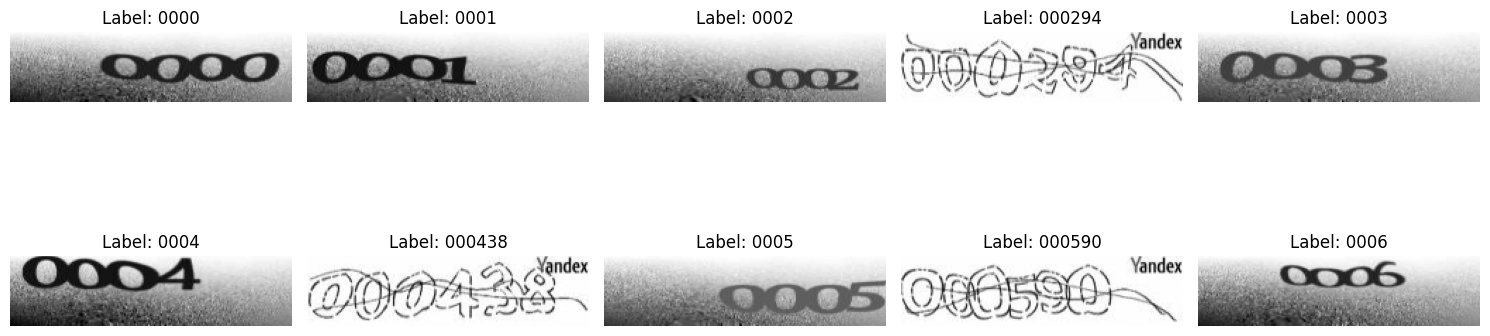

In [ ]:
import matplotlib.pyplot as plt

def visualize_samples(dataset, n=10):
    # Determine grid size (e.g., 5 columns per row)
    cols = 5
    rows = (n // cols) + (1 if n % cols != 0 else 0)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() # Flatten the 2D array of axes for easy looping

    for i in range(n):
        # Pull data from your PyTorch Dataset
        img_tensor, label_tensor, length = dataset[i]

        # 1. Reconstruct the string from the numeric tensor
        label_str = "".join([NUM_TO_CHAR[idx.item()] for idx in label_tensor])

        # 2. Prepare image for plotting
        # Tensors are [Channels, Height, Width]. Matplotlib wants [Height, Width] for grayscale.
        img_display = img_tensor.squeeze().numpy()

        # Plot
        axes[i].imshow(img_display, cmap='gray')
        axes[i].set_title(f"Label: {label_str}")
        axes[i].axis('off') # Hide gridlines and numbers

    # Hide any extra empty subplots if 'n' isn't a perfect multiple of 'cols'
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Show the first 10 elements in a 2-row table
visualize_samples(full_dataset, n=10)

Colab Cell 3: CRNN Model Definition

In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        # CNN (Feature Extraction)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d((2, 1))
        )
        # RNN (Sequence Modeling)
        self.rnn = nn.LSTM(1536, RNN_HIDDEN_SIZE, bidirectional=True, num_layers=RNN_LAYERS, batch_first=False)
        self.fc = nn.Linear(512, num_classes + 1)

    def forward(self, x):
        # x: [batch, 1, 50, 200]
        features = self.cnn(x) # [batch, 256, 6, 50]
        b, c, h, w = features.size()
        features = features.view(b, c * h, w) # [batch, 1536, 50]
        features = features.permute(2, 0, 1)  # [width/time, batch, features]

        out, _ = self.rnn(features)
        out = self.fc(out) # [50, batch, num_classes]
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(len(CHAR_TO_NUM)).to(device)
print(f"Model initialized on {device}")

Model initialized on cuda


Colab Cell 4: Training Loop

We use nn.CTCLoss here. It handles the alignment between the sequence and the image automatically.

In [ ]:
import time
import torch.optim as optim
import torch

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 1. INITIALIZE THE SCALER
# This object monitors the gradients and multiplies/divides them to prevent Underflow.
scaler = torch.amp.GradScaler('cuda')

def train(epochs=5):
    model.train()

    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0

        for imgs, labels, label_lens in train_loader:
            imgs = imgs.to(device)
            # IMPORTANT: For AMP to work smoothly with CTCLoss, ensure labels are also on the GPU
            labels = labels.to(device)

            optimizer.zero_grad()

            # 2. ENTER THE AUTOCAST CONTEXT
            # Everything inside this 'with' block is automatically cast to fast FP16 math
            with torch.amp.autocast('cuda'):
                logits = model(imgs) # [50, B, classes]
                log_probs = logits.log_softmax(2)

                # Make sure the input lengths tensor is also created on the target device
                input_lengths = torch.full((BATCH_SIZE,), logits.size(0), dtype=torch.long, device=device)

                loss = criterion(log_probs, labels, input_lengths, label_lens)

            # 3. SCALED BACKWARD PASS
            # Instead of loss.backward(), we scale the loss first to prevent 16-bit underflow
            scaler.scale(loss).backward()

            # 4. SCALED OPTIMIZER STEP
            # Unscales the gradients and updates the weights
            scaler.step(optimizer)

            # 5. UPDATE SCALER
            # The scaler checks if any underflow/overflow happened and adjusts its multiplier for the next batch
            scaler.update()

            total_loss += loss.item()

        end_time = time.time()

        # Calculate minutes and seconds
        elapsed_time = end_time - start_time
        mins = int(elapsed_time // 60)
        secs = int(elapsed_time % 60)

        # Print a much cleaner, formatted output
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Time: {mins}m {secs}s")

print("Starting accelerated training...")
train(epochs=EPOCHS)

Starting accelerated training...
Epoch [1/10] | Loss: 4.2445 | Time: 1m 38s
Epoch [2/10] | Loss: 3.5848 | Time: 1m 37s
Epoch [3/10] | Loss: 3.3352 | Time: 1m 30s
Epoch [4/10] | Loss: 3.1974 | Time: 1m 30s
Epoch [5/10] | Loss: 3.0458 | Time: 1m 29s
Epoch [6/10] | Loss: 2.8900 | Time: 1m 28s
Epoch [7/10] | Loss: 2.7136 | Time: 1m 26s
Epoch [8/10] | Loss: 2.5038 | Time: 1m 27s
Epoch [9/10] | Loss: 2.2805 | Time: 1m 28s
Epoch [10/10] | Loss: 2.0455 | Time: 1m 27s


1 epoch take 4min8s

In [ ]:
# ==========================================
# SAVE THE MODEL
# ==========================================
import os

# Define the file name (the .pth extension is standard for PyTorch)
SAVE_PATH = "best_captcha_crnn.pth"

# Extract the learned math (weights and biases)
model_weights = model.state_dict()

# Save it to the hard drive
torch.save(model_weights, SAVE_PATH)

# Check the file size to ensure it saved properly
file_size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
print(f"✅ Model weights successfully saved to: '{SAVE_PATH}' ({file_size_mb:.2f} MB)")

✅ Model weights successfully saved to: 'best_captcha_crnn.pth' (23.82 MB)


Colab Cell 5: Testing & Prediction

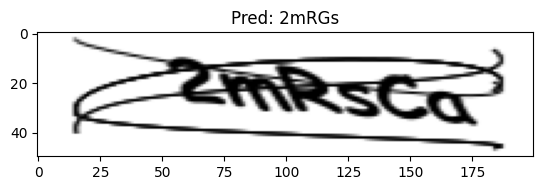

In [ ]:
import matplotlib.pyplot as plt

def decode_prediction(logits):
    tokens = logits.argmax(2).permute(1, 0) # [batch, width]
    res = []
    for token in tokens:
        chars = []
        prev = -1
        for t in token:
            t = t.item()
            if t != 0 and t != prev:
                chars.append(NUM_TO_CHAR[t])
            prev = t
        res.append("".join(chars))
    return res

model.eval()
imgs, labels, _ = next(iter(test_loader))
with torch.no_grad():
    logits = model(imgs.to(device))
    predictions = decode_prediction(logits)

# Show first result
plt.imshow(imgs[0].squeeze(), cmap='gray')
plt.title(f"Pred: {predictions[0]}")
plt.show()

In [ ]:
# 1. Create a fresh, dumb model skeleton
loaded_model = CRNN(len(CHAR_TO_NUM)).to(device)

# 2. Load the brain (the weights) from the file
saved_brain = torch.load("best_captcha_crnn.pth", weights_only=True)

# 3. Pour the brain into the skeleton
loaded_model.load_state_dict(saved_brain)

print("Model successfully resurrected and ready to predict!")

Model successfully resurrected and ready to predict!


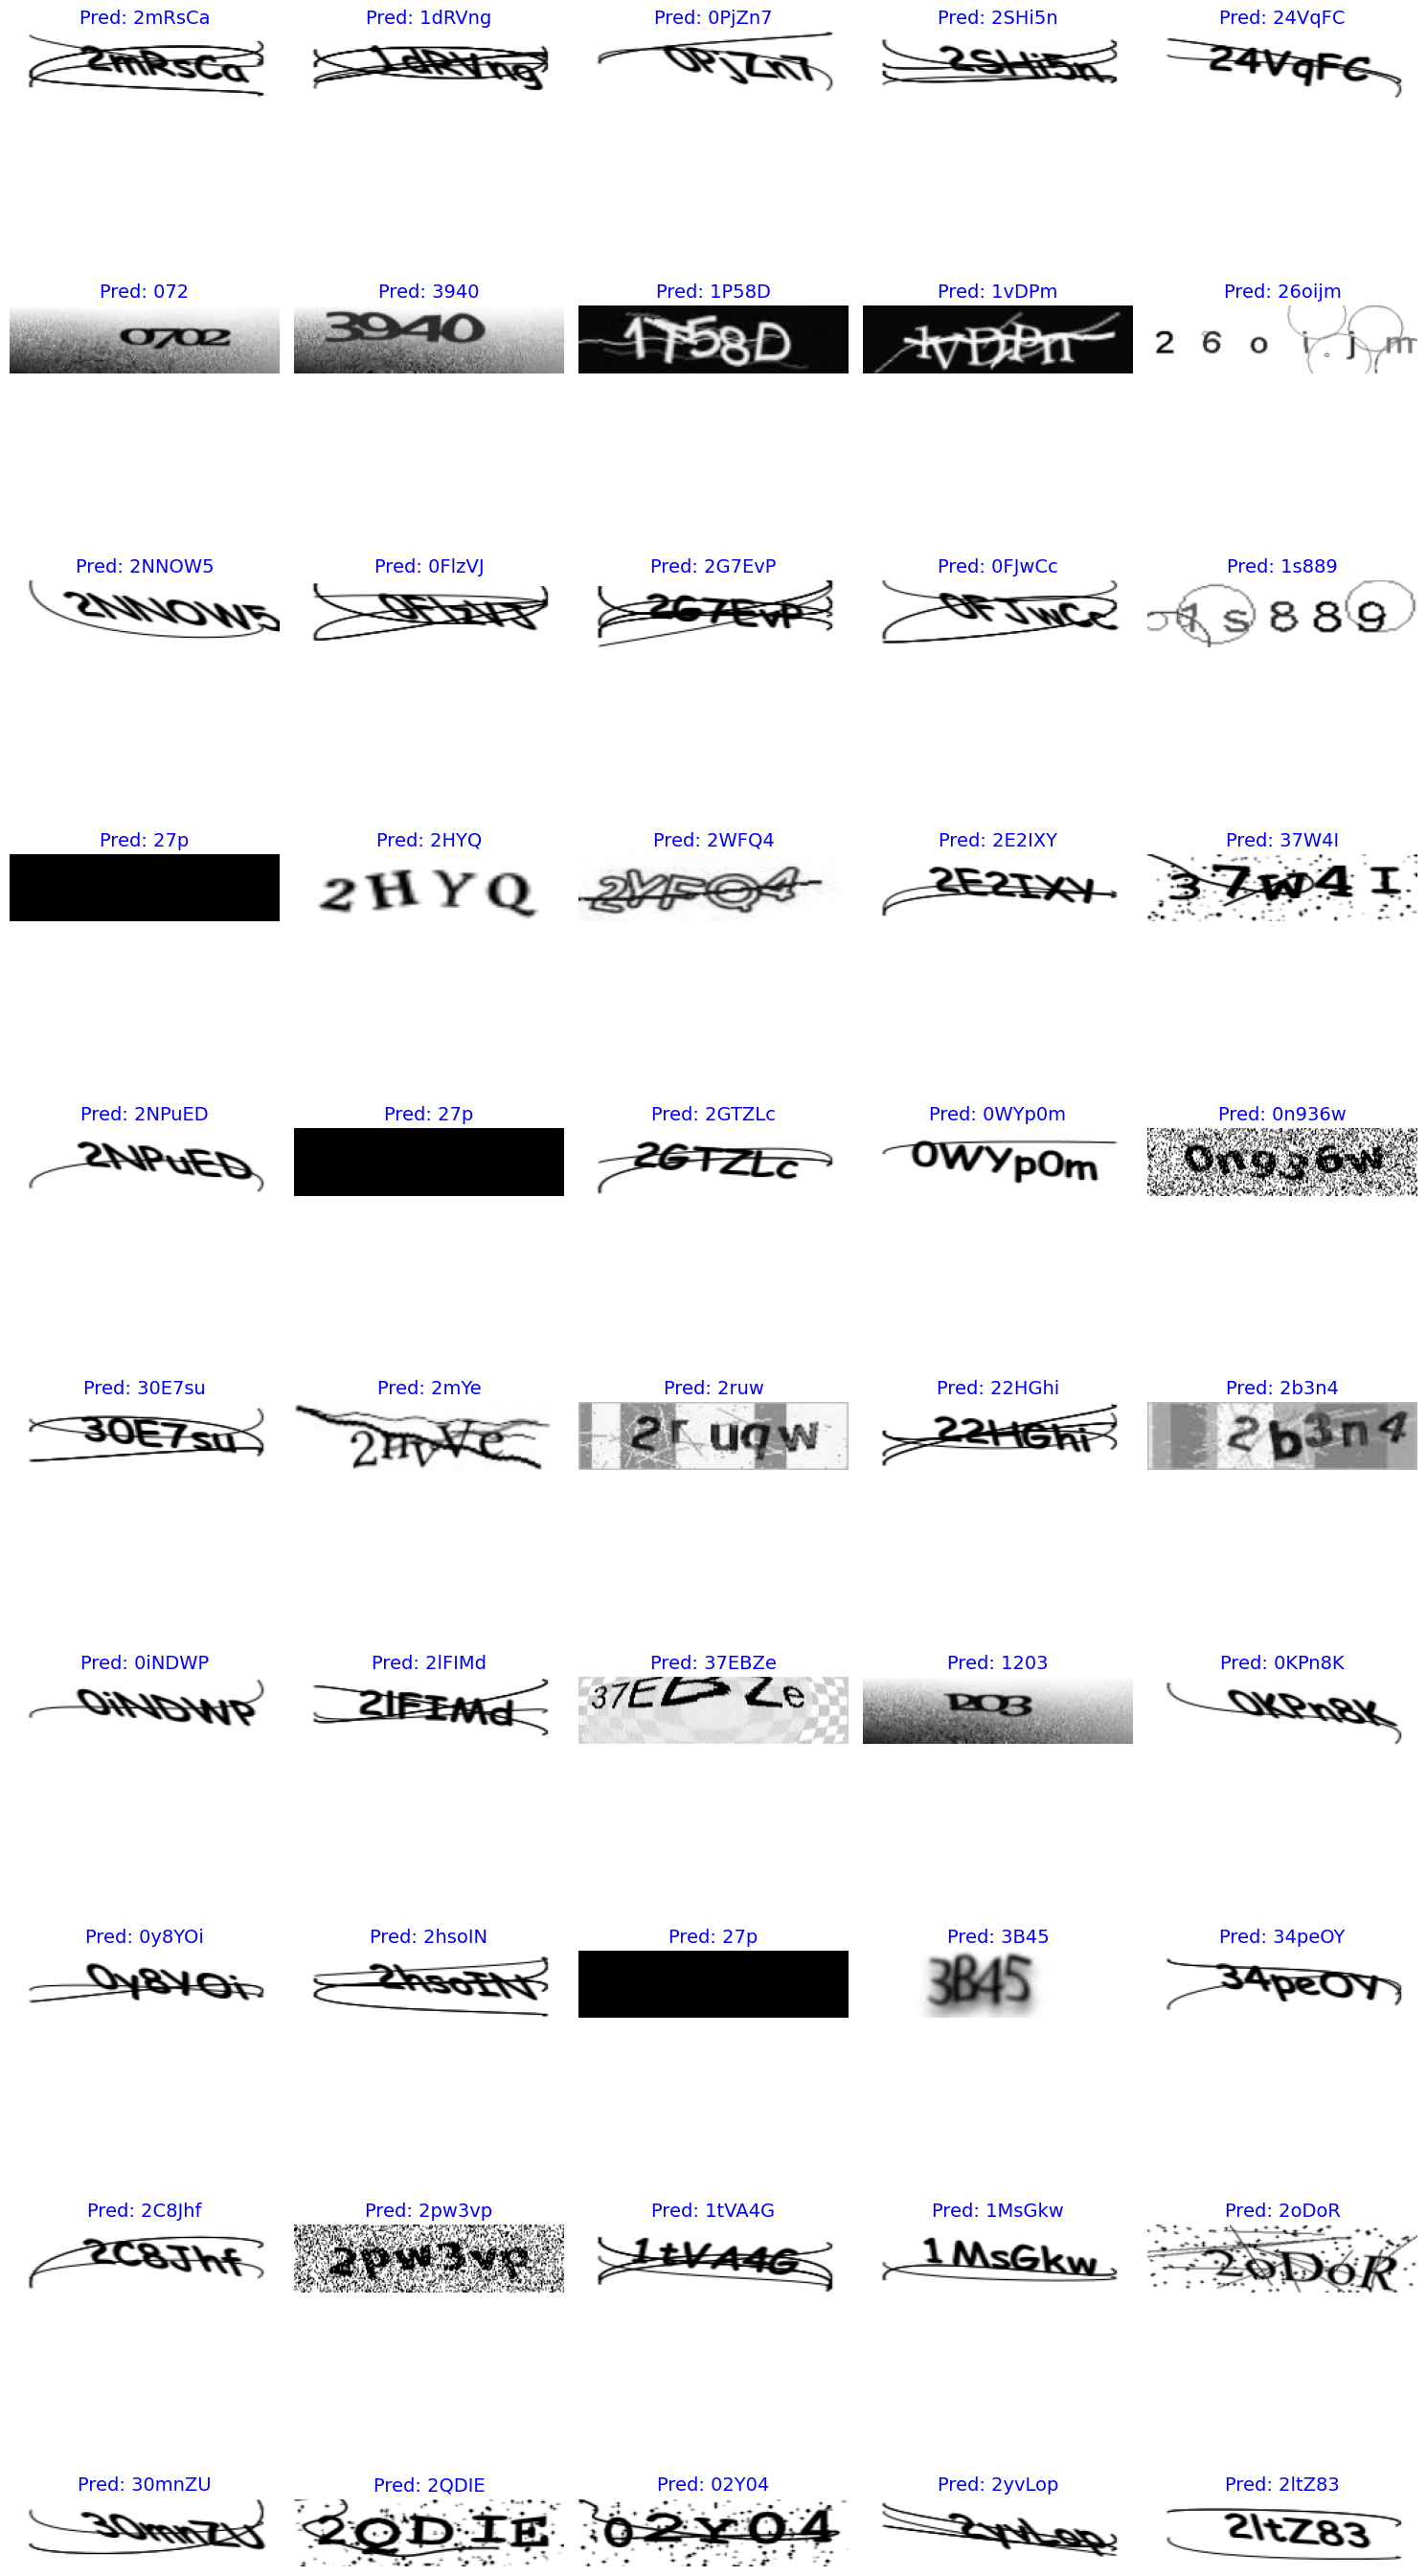

In [ ]:
import matplotlib.pyplot as plt

# --- CONTROL KNOB ---
NUM_IMAGES_TO_SHOW = 50 # Change this to 5, 10, etc.

def decode_prediction(logits):
    # Performance fix: move to CPU and convert to numpy BEFORE the loop
    tokens = logits.argmax(2).permute(1, 0).cpu().numpy()
    res = []
    for token in tokens:
        chars = []
        prev = -1
        for t in token:
            if t != 0 and t != prev:
                chars.append(NUM_TO_CHAR[t])
            prev = t
        res.append("".join(chars))
    return res

loaded_model.eval()
imgs, labels, _ = next(iter(test_loader))
with torch.no_grad():
    logits = loaded_model(imgs.to(device))
    predictions = decode_prediction(logits)

# --- NEW VISUALIZATION LOGIC ---
# Ensure we don't try to show more images than we have in our batch
num_to_show = min(NUM_IMAGES_TO_SHOW, BATCH_SIZE)

# Calculate how many rows and columns we need (max 5 columns per row for readability)
cols = min(num_to_show, 5)
rows = (num_to_show // cols) + (1 if num_to_show % cols != 0 else 0)

# Create a grid
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))

# Flatten the axes array to make looping easier (in case of multiple rows)
if num_to_show > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Handle the edge case where we only show 1 image

for i in range(num_to_show):
    # Squeeze removes the channel dimension [1, 50, 200] -> [50, 200]
    img_display = imgs[i].squeeze().cpu().numpy()

    axes[i].imshow(img_display, cmap='gray')
    axes[i].set_title(f"Pred: {predictions[i]}", fontsize=14, color='blue')
    axes[i].axis('off') # Hide the axis ticks for a cleaner look

# Hide any empty subplots if the grid isn't perfectly filled
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Task 1: Calculate the histogram of the image (if you have time, try doing some image enhancement). Try applying a binary mask to isolate the object and extract all the shape features.



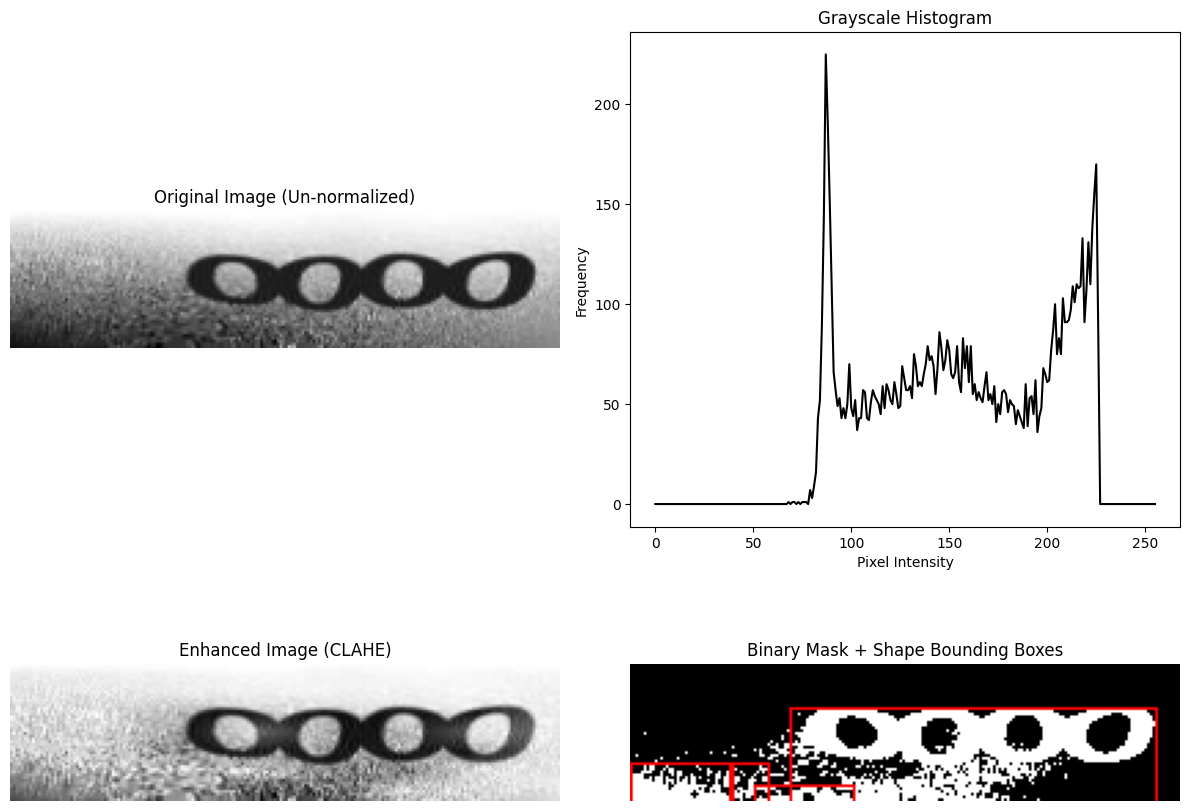

Extracted 4 valid shapes.
Shape 4: Area=81.0, Perimeter=98.77, Centroid=(62, 47)
Shape 28: Area=20.5, Perimeter=49.70, Centroid=(41, 44)
Shape 32: Area=222.5, Perimeter=157.98, Centroid=(14, 45)
Shape 53: Area=2728.5, Perimeter=530.32, Centroid=(123, 29)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab a single sample from your already-loaded dataset
# We use full_dataset from your earlier code
img_tensor, label_tensor, length = full_dataset[0]

# --- PREPARATION ---
# Un-normalize the image: it was normalized with mean=0.5, std=0.5
# Formula: img = (img * std) + mean
img_np = (img_tensor.squeeze().numpy() * 0.5) + 0.5
# Scale to 0-255 and convert to uint8 for OpenCV
img_uint8 = (img_np * 255).astype(np.uint8)

# --- A. HISTOGRAM ---
# Calculate the histogram for the grayscale image
hist = cv2.calcHist([img_uint8], [0], None, [256], [0, 256])

# --- B. IMAGE ENHANCEMENT ---
# Using CLAHE (Contrast Limited Adaptive Histogram Equalization)
# This improves contrast, making it easier to separate text from the background
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_img = clahe.apply(img_uint8)

# --- C. BINARY MASK ---
# Use Otsu's thresholding to automatically find the best threshold value.
# We use THRESH_BINARY_INV so the text becomes white (255) and background black (0).
_, binary_mask = cv2.threshold(enhanced_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- D. SHAPE FEATURES ---
# Find contours (the outlines of the isolated objects/characters)
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

shape_features = []
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)

    # Optional: Filter out tiny specs of noise
    if area > 15:
        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)

        # Calculate moments to find the centroid
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0

        shape_features.append({
            'contour_id': i,
            'area': area,
            'perimeter': perimeter,
            'bounding_box': (x, y, w, h),
            'centroid': (cx, cy)
        })

# ==========================================
# VISUALIZE EVERYTHING
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Image & Histogram
axes[0, 0].imshow(img_uint8, cmap='gray')
axes[0, 0].set_title("Original Image (Un-normalized)")
axes[0, 0].axis('off')

axes[0, 1].plot(hist, color='black')
axes[0, 1].set_title("Grayscale Histogram")
axes[0, 1].set_xlabel("Pixel Intensity")
axes[0, 1].set_ylabel("Frequency")

# 2. Enhanced Image
axes[1, 0].imshow(enhanced_img, cmap='gray')
axes[1, 0].set_title("Enhanced Image (CLAHE)")
axes[1, 0].axis('off')

# 3. Binary Mask with Bounding Boxes
# Convert mask to RGB so we can draw colored boxes on it
mask_bgr = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
for feature in shape_features:
    x, y, w, h = feature['bounding_box']
    cv2.rectangle(mask_bgr, (x, y), (x + w, y + h), (255, 0, 0), 1) # Red boxes

axes[1, 1].imshow(mask_bgr)
axes[1, 1].set_title("Binary Mask + Shape Bounding Boxes")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Print the extracted features
print(f"Extracted {len(shape_features)} valid shapes.")
for feat in shape_features[:5]: # Print first 5
    print(f"Shape {feat['contour_id']}: Area={feat['area']}, Perimeter={feat['perimeter']:.2f}, Centroid={feat['centroid']}")